<a href="https://colab.research.google.com/github/Dogbware/Mineria_datos/blob/main/Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

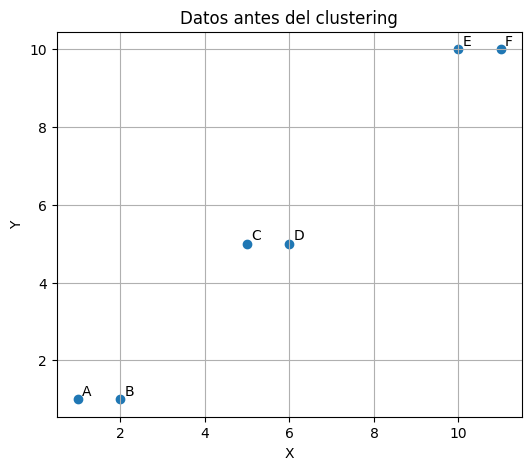

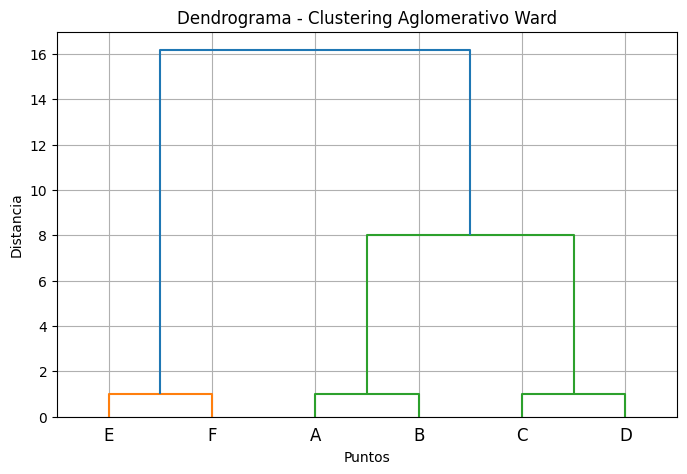

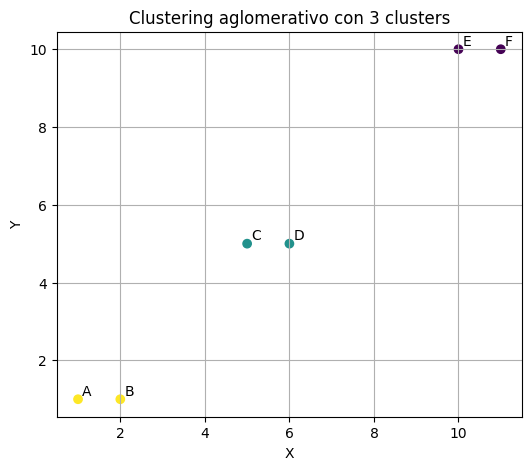

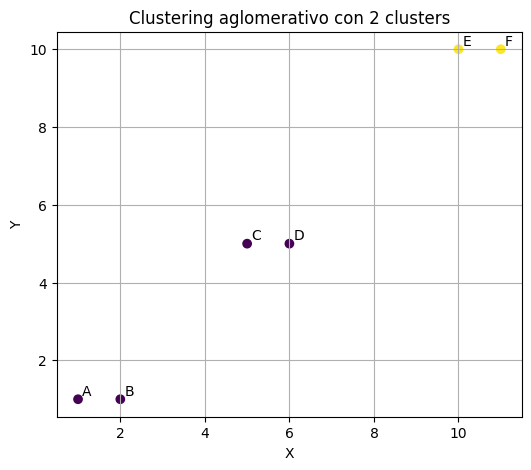

Clusters con 3 grupos:
A -> Cluster 2
B -> Cluster 2
C -> Cluster 1
D -> Cluster 1
E -> Cluster 0
F -> Cluster 0

Clusters con 2 grupos:
A -> Cluster 0
B -> Cluster 0
C -> Cluster 0
D -> Cluster 0
E -> Cluster 1
F -> Cluster 1


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Datos
X = np.array([
    [1, 1],    # A
    [2, 1],    # B
    [5, 5],    # C
    [6, 5],    # D
    [10,10],   # E
    [11,10]    # F
])

etiquetas = ["A", "B", "C", "D", "E", "F"]

# 1. Graficar datos antes del clustering
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1])

for i, txt in enumerate(etiquetas):
    plt.text(X[i, 0] + 0.1, X[i, 1] + 0.1, txt)

plt.title("Datos antes del clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()


# 2. Generar dendrograma con linkage='ward'
Z = linkage(X, method="ward")

plt.figure(figsize=(8, 5))
dendrogram(Z, labels=etiquetas)
plt.title("Dendrograma - Clustering Aglomerativo Ward")
plt.xlabel("Puntos")
plt.ylabel("Distancia")
plt.grid(True)
plt.show()


# 3. Cortar el árbol para formar 3 clusters
modelo_3 = AgglomerativeClustering(n_clusters=3, linkage="ward")
clusters_3 = modelo_3.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters_3)

for i, txt in enumerate(etiquetas):
    plt.text(X[i, 0] + 0.1, X[i, 1] + 0.1, txt)

plt.title("Clustering aglomerativo con 3 clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()


# 4. Cortar el árbol para formar 2 clusters
modelo_2 = AgglomerativeClustering(n_clusters=2, linkage="ward")
clusters_2 = modelo_2.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters_2)

for i, txt in enumerate(etiquetas):
    plt.text(X[i, 0] + 0.1, X[i, 1] + 0.1, txt)

plt.title("Clustering aglomerativo con 2 clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()


# Mostrar resultados en consola
print("Clusters con 3 grupos:")
for etiqueta, cluster in zip(etiquetas, clusters_3):
    print(etiqueta, "-> Cluster", cluster)

print("\nClusters con 2 grupos:")
for etiqueta, cluster in zip(etiquetas, clusters_2):
    print(etiqueta, "-> Cluster", cluster)

1. ¿Qué puntos se unen primero y por qué?

Primero se unen los puntos más cercanos entre sí:

A con B
C con D
E con F

Esto pasa porque cada par tiene una distancia muy pequeña.

2. ¿Qué sucede al cortar el dendrograma en una altura pequeña?

Si cortas el dendrograma en una altura pequeña, se forman más clusters.

3. ¿Qué cambia al cortar el árbol más arriba?

Cuando cortas más arriba, permites que se unan grupos que están más separados.

Por eso, en vez de tener 3 clusters:

[A, B]   [C, D]   [E, F]

puedes terminar con 2 clusters:

[A, B, C, D]   [E, F]

Mientras más arriba cortes, menos clusters tendrás.
4. ¿Qué significa la altura donde se unen dos ramas?

La altura representa la distancia o diferencia entre los grupos que se están uniendo.

Si dos ramas se unen abajo, significa que los puntos o grupos son muy parecidos.
Si se unen muy arriba, significa que son más diferentes entre sí.

5. ¿Cuántos clusters aparecen al cortar aproximadamente en distancia 8?

Al cortar aproximadamente en distancia 8, aparecen entre 2 y 3 clusters dependiendo de si el corte se hace justo antes o justo después de esa unión. Si se considera la unión en 8, quedan 2 clusters.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Datos
X = np.array([
    [20, 100],
    [22, 120],
    [23, 140],
    [45, 700],
    [46, 750],
    [48, 720],
    [60, 1500],
    [62, 1600]
])

clientes = [
    "Cliente 1",
    "Cliente 2",
    "Cliente 3",
    "Cliente 4",
    "Cliente 5",
    "Cliente 6",
    "Cliente 7",
    "Cliente 8"
]

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Graficar los datos originales
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1])

for i, cliente in enumerate(clientes):
    plt.text(X[i, 0] + 0.3, X[i, 1] + 20, cliente)

plt.title("Clientes antes del clustering")
plt.xlabel("Edad")
plt.ylabel("Gasto mensual")
plt.grid(True)
plt.show()


# 2. Generar dendrograma
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(9, 5))
dendrogram(Z, labels=clientes)
plt.title("Dendrograma - Clustering Aglomerativo")
plt.xlabel("Clientes")
plt.ylabel("Distancia")
plt.grid(True)
plt.show()


# 3. Probar con n_clusters=2
modelo_2 = AgglomerativeClustering(n_clusters=2, linkage="ward")
clusters_2 = modelo_2.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters_2)

for i, cliente in enumerate(clientes):
    plt.text(X[i, 0] + 0.3, X[i, 1] + 20, cliente)

plt.title("Segmentación de clientes con 2 clusters")
plt.xlabel("Edad")
plt.ylabel("Gasto mensual")
plt.grid(True)
plt.show()


# 4. Probar con n_clusters=3
modelo_3 = AgglomerativeClustering(n_clusters=3, linkage="ward")
clusters_3 = modelo_3.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters_3)

for i, cliente in enumerate(clientes):
    plt.text(X[i, 0] + 0.3, X[i, 1] + 20, cliente)

plt.title("Segmentación de clientes con 3 clusters")
plt.xlabel("Edad")
plt.ylabel("Gasto mensual")
plt.grid(True)
plt.show()


# Mostrar resultados
print("Resultados con 2 clusters:")
for cliente, dato, cluster in zip(clientes, X, clusters_2):
    print(cliente, dato, "-> Cluster", cluster)

print("\nResultados con 3 clusters:")
for cliente, dato, cluster in zip(clientes, X, clusters_3):
    print(cliente, dato, "-> Cluster", cluster)

1. ¿Qué clientes parecen más similares?

Los clientes más similares son los que tienen edades y gastos parecidos.

2. ¿Qué grupos naturales identifica el algoritmo?

El algoritmo identifica tres grupos naturales:

Grupo 1: clientes jóvenes con bajo gasto
Grupo 2: clientes adultos con gasto medio
Grupo 3: clientes mayores con gasto alto

3. ¿Qué representa cada cluster desde el punto de vista comercial?

El cluster joven representa a clientes con edad baja y gasto bajo. Comercialmente, se pueden interpretar como clientes nuevos, jóvenes o con menor poder de compra.

El cluster adulto representa a clientes de edad media y gasto medio. Este grupo puede interpretarse como clientes con un consumo más estable y constante.

El cluster mayor representa a clientes con edad alta y gasto alto. Desde el punto de vista comercial, son clientes de alto valor para la tienda, ya que generan mayores ingresos por su nivel de gasto.


El grupo más importante comercialmente sería el de clientes con gasto alto, porque representan mayores ingresos.

4. ¿Cuál sería una estrategia de marketing para cada grupo?

Para los clientes jóvenes con gasto bajo, una buena estrategia sería ofrecer promociones, descuentos, cupones o productos económicos para aumentar su consumo.

Para los clientes adultos con gasto medio, convendría usar programas de fidelización, paquetes especiales o recomendaciones personalizadas para mantenerlos comprando.

Para los clientes mayores con gasto alto, se podrían ofrecer beneficios exclusivos, atención personalizada, membresías premium o promociones para clientes frecuentes, ya que son los que más gastan.

5. ¿Por qué el algoritmo agrupa ciertos clientes?

El algoritmo agrupa clientes porque calcula qué tan parecidos son según sus características, en este caso:

Edad
Gasto mensual

Los clientes que tienen valores cercanos se unen primero. Por eso, los clientes jóvenes quedan juntos, los adultos quedan juntos y los de mayor gasto también forman su propio grupo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Datos
X = np.array([
    [95, 98],  # Alumno A
    [92, 94],  # Alumno B
    [88, 90],  # Alumno C
    [65, 70],  # Alumno D
    [60, 68],  # Alumno E
    [58, 62],  # Alumno F
    [30, 40],  # Alumno G
    [35, 38]   # Alumno H
])

alumnos = ["A", "B", "C", "D", "E", "F", "G", "H"]

# Graficar datos originales
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1])

for i, alumno in enumerate(alumnos):
    plt.text(X[i, 0] + 0.5, X[i, 1] + 0.5, alumno)

plt.title("Datos de rendimiento académico")
plt.xlabel("Promedio")
plt.ylabel("Asistencia")
plt.grid(True)
plt.show()


# Dendrograma
Z = linkage(X, method="ward")

plt.figure(figsize=(9, 5))
dendrogram(Z, labels=alumnos)
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Alumnos")
plt.ylabel("Distancia")
plt.grid(True)
plt.show()


# Clustering con 2 clusters
modelo_2 = AgglomerativeClustering(n_clusters=2, linkage="ward")
clusters_2 = modelo_2.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters_2)

for i, alumno in enumerate(alumnos):
    plt.text(X[i, 0] + 0.5, X[i, 1] + 0.5, alumno)

plt.title("Clustering con 2 clusters")
plt.xlabel("Promedio")
plt.ylabel("Asistencia")
plt.grid(True)
plt.show()


# Clustering con 3 clusters
modelo_3 = AgglomerativeClustering(n_clusters=3, linkage="ward")
clusters_3 = modelo_3.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=clusters_3)

for i, alumno in enumerate(alumnos):
    plt.text(X[i, 0] + 0.5, X[i, 1] + 0.5, alumno)

plt.title("Clustering con 3 clusters")
plt.xlabel("Promedio")
plt.ylabel("Asistencia")
plt.grid(True)
plt.show()


# Mostrar resultados
print("Resultados con 2 clusters:")
for alumno, dato, cluster in zip(alumnos, X, clusters_2):
    print("Alumno", alumno, dato, "-> Cluster", cluster)

print("\nResultados con 3 clusters:")
for alumno, dato, cluster in zip(alumnos, X, clusters_3):
    print("Alumno", alumno, dato, "-> Cluster", cluster)

1. ¿Qué alumnos se parecen más?

Los alumnos más parecidos son los que tienen valores cercanos de promedio y asistencia.

Por ejemplo, los alumnos A y B se parecen mucho porque ambos tienen promedio y asistencia altos.

También se parecen los alumnos D y E, porque tienen rendimiento medio y valores cercanos.

Los alumnos G y H también son muy similares porque ambos tienen bajo promedio y baja asistencia.

2. ¿Qué perfiles de estudiantes aparecen?

Aparecen tres perfiles principales.

El primer perfil es el de alto rendimiento, formado por los alumnos A, B y C. Estos estudiantes tienen buen promedio y buena asistencia.

El segundo perfil es el de rendimiento medio, formado por los alumnos D, E y F. Estos alumnos no están mal, pero podrían mejorar tanto en promedio como en asistencia.

El tercer perfil es el de bajo rendimiento, formado por los alumnos G y H. Estos estudiantes presentan bajo promedio y baja asistencia.

3. ¿Qué decisión institucional podría tomarse con esta información?

La escuela podría crear estrategias diferentes para cada grupo.

A los alumnos de alto rendimiento se les podrían ofrecer reconocimientos, becas, tutorías avanzadas o actividades especiales.

A los alumnos de rendimiento medio se les podría dar seguimiento para evitar que bajen su desempeño.

A los alumnos de bajo rendimiento se les debería dar apoyo académico, asesorías, seguimiento con tutores y comunicación con sus familias.

4. ¿Qué ocurre cuando el número de clusters cambia?

Cuando se usan 2 clusters, los datos se agrupan de forma más general. Solo se distingue entre alumnos con alto rendimiento y alumnos que necesitan más atención.

Cuando se usan 3 clusters, el análisis es más detallado, porque separa a los alumnos en alto, medio y bajo rendimiento.

Mientras más clusters se usen, más específicos son los grupos, pero también puede ser más difícil interpretarlos.

5. ¿Qué grupo requeriría más intervención académica?

El grupo que requiere más intervención académica es el formado por los alumnos G y H, porque tienen los promedios y asistencias más bajos.

Este grupo necesita más apoyo, ya que su bajo rendimiento podría estar relacionado con problemas de aprendizaje, falta de asistencia, desmotivación o dificultades personales.